<a href="https://colab.research.google.com/github/dyjdlopez/intro_2_quantum/blob/main/qiskit/04_02_qaoa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fiesta QKP — QAOA with Qamomile

This notebook continues from `fiesta_qkp_qubo.json` produced in the previous notebook.
We convert the saved QUBO into a **QAOA circuit** using [Qamomile](https://jij-inc-qamomile.readthedocs-hosted.com/latest/en/),
simulate it with Qiskit Aer, and compare the result against the classical optimum.

---

## What is QAOA?

The **Quantum Approximate Optimization Algorithm (QAOA)** is a variational quantum algorithm
designed for combinatorial optimisation problems. It belongs to the broader family of
**Variational Quantum Algorithms (VQAs)**, where a parameterised quantum circuit is optimised
by a classical outer loop.

### The two Hamiltonians

QAOA alternates between two unitary operators, each derived from a Hamiltonian:

**1. Problem (cost) Hamiltonian $H_C$**

Encodes the objective function. For a QUBO with binary variables $x_i \in \{0,1\}$,
we first map to spin variables $s_i \in \{-1,+1\}$ via $x_i = (1 - s_i)/2$,
then express $H_C$ as a sum of Pauli-Z operators:

$$H_C = \sum_i h_i Z_i + \sum_{i<j} J_{ij} Z_i Z_j$$

The ground state of $H_C$ corresponds to the optimal solution.
The cost unitary is $U_C(\gamma) = e^{-i\gamma H_C}$, implemented as a layer of
$R_{ZZ}$ and $R_Z$ gates.

**2. Mixer Hamiltonian $H_B$**

Drives transitions between computational basis states, preventing the circuit
from getting trapped. The standard mixer is:

$$H_B = \sum_i X_i$$

The mixer unitary is $U_B(\beta) = e^{-i\beta H_B} = \bigotimes_i R_X(2\beta)$,
implemented as a layer of single-qubit $R_X$ gates.

### The QAOA circuit

Starting from the uniform superposition $|+\rangle^{\otimes n}$, the circuit applies
$p$ alternating layers:

$$|\psi(\boldsymbol{\gamma}, \boldsymbol{\beta})\rangle =
U_B(\beta_p)\, U_C(\gamma_p) \cdots U_B(\beta_1)\, U_C(\gamma_1)\, |+\rangle^{\otimes n}$$

The $2p$ parameters $(\boldsymbol{\gamma}, \boldsymbol{\beta})$ are optimised classically
to minimise $\langle \psi | H_C | \psi \rangle$. As $p \to \infty$, QAOA converges to
the exact optimum.


## 0 · Setup

In [ ]:
# Install dependencies (run once)
# !pip install qamomile qiskit qiskit-aer pylatexenc

In [99]:
import json
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

with open('fiesta_qkp_qubo.json', 'r') as f:
    data = json.load(f)

offset  = data['offset']
qubo = {tuple(map(int, k.split(','))): v - offset for k, v in data['qubo'].items()}
n = data['n']
ITEMS = data['items']
weights = np.array(data['weights'])
W_cap = data['W_cap']
V = np.array([
    [ 8, 10, 11,  2],
    [10,  7, 12,  2],
    [11, 12,  3,  2],
    [ 2,  2,  2,  1],
], dtype=float)

print(f'Loaded QUBO with {len(qubo)} entries')
print(f'Items   : {ITEMS}')
print(f'Weights : {weights.astype(int)}')
print(f'W_cap   : {int(W_cap)}')
print(f'Offset  : {offset}')

Loaded QUBO with 36 entries
Items   : ['SHANG', 'BBQ', 'RICE', 'CD']
Weights : [ 40 200 100  20]
W_cap   : 300
Offset  : 90000.0


In [100]:
def evaluate(x_vec):
    """Return (Z, weight_used, is_feasible) for a binary vector x."""
    x_vec = np.asarray(x_vec)
    Z  = sum(V[i, i] * x_vec[i] for i in range(n))
    Z += sum(V[i, j] * x_vec[i] * x_vec[j]
             for i in range(n) for j in range(i+1, n))
    w_used   = float(weights @ x_vec)
    feasible = w_used <= W_cap
    return float(Z), w_used, feasible

x_opt = np.array([1, 1, 0, 1])
Z_classical = evaluate(x_opt)[0]
print(f'Classical optimum Z = {Z_classical}')

Classical optimum Z = 30.0


---
## 1 · Build the OMMX instance from QUBO

`QAOAConverter` expects an OMMX instance. We build one directly from the QUBO
using `ommx.v1.Instance.from_qubo()`.

In [111]:
from qamomile.optimization.binary_model import BinaryModel, VarType

model = BinaryModel.from_qubo(qubo)

print(model)

---
## 2 · Cost Hamiltonian via QAOAConverter

`QAOAConverter` converts the OMMX instance to a **spin model** (Ising form)
and builds the cost Hamiltonian as a sum of Pauli-Z operators.
We normalise by the absolute maximum coefficient to keep gate angles well-conditioned.

In [102]:
from qamomile.optimization.qaoa import QAOAConverter

converter = QAOAConverter(model)
converter.spin_model = converter.spin_model.normalize_by_rms()
hamiltonian = converter.get_cost_hamiltonian()

print(f'Number of variables: {model.num_bits}')
print(f'Variable type: {model.vartype}')
print(hamiltonian)
print(f'\nNumber of Pauli terms : {len(hamiltonian)}')
print(f'Number of qubits      : {n}')

Number of variables: 8
Variable type: BINARY
Hamiltonian((Z0,): 1.0015151576221115, (Z1,): 0.9776339341077236, (Z2,): 0.9925502152185018, (Z3,): 1.004461598875462, (Z4,): 1.004451648883893, (Z5,): 1.001466651413213, (Z6,): 0.9954966564718525, (Z7,): 0.9835566665891315, (Z0, Z1): -0.09204985950210119, (Z0, Z2): -0.10200109481998137, (Z0, Z3): -0.10994989433461357, (Z0, Z4): -0.10994740683672133, (Z0, Z5): -0.10795740852293452, (Z0, Z6): -0.1039774118953609, (Z0, Z7): -0.09601741864021365, (Z1, Z2): -0.06220237229319126, (Z1, Z3): -0.10198990107946632, (Z1, Z4): -0.1019874135815741, (Z1, Z5): -0.09203742201264004, (Z1, Z6): -0.07213743887477192, (Z1, Z7): -0.03233747259903569, (Z2, Z3): -0.10696489686393335, (Z2, Z4): -0.10696240936604112, (Z2, Z5): -0.1019874135815741, (Z2, Z6): -0.09203742201264004, (Z2, Z7): -0.07213743887477192, (Z3, Z4): -0.11094240599361474, (Z3, Z5): -0.10994740683672133, (Z3, Z6): -0.10795740852293452, (Z3, Z7): -0.1039774118953609, (Z4, Z5): -0.10994740683672133

---
## 3 · Transpile to Qiskit circuit

`QiskitTranspiler` converts the Qamomile QAOA ansatz to a Qiskit `QuantumCircuit`.
The parameter `p` is the number of QAOA layers — more layers give a better
approximation at the cost of more gates and parameters.

In [103]:
from qamomile.qiskit import QiskitTranspiler

transpiler = QiskitTranspiler()
p = 3 # number of QAOA layers
executable = converter.transpile(transpiler, p=p)

print(f'QAOA circuit transpiled with p = {p} layers.')

QAOA circuit transpiled with p = 3 layers.


---
## 4 · Circuit visualisation

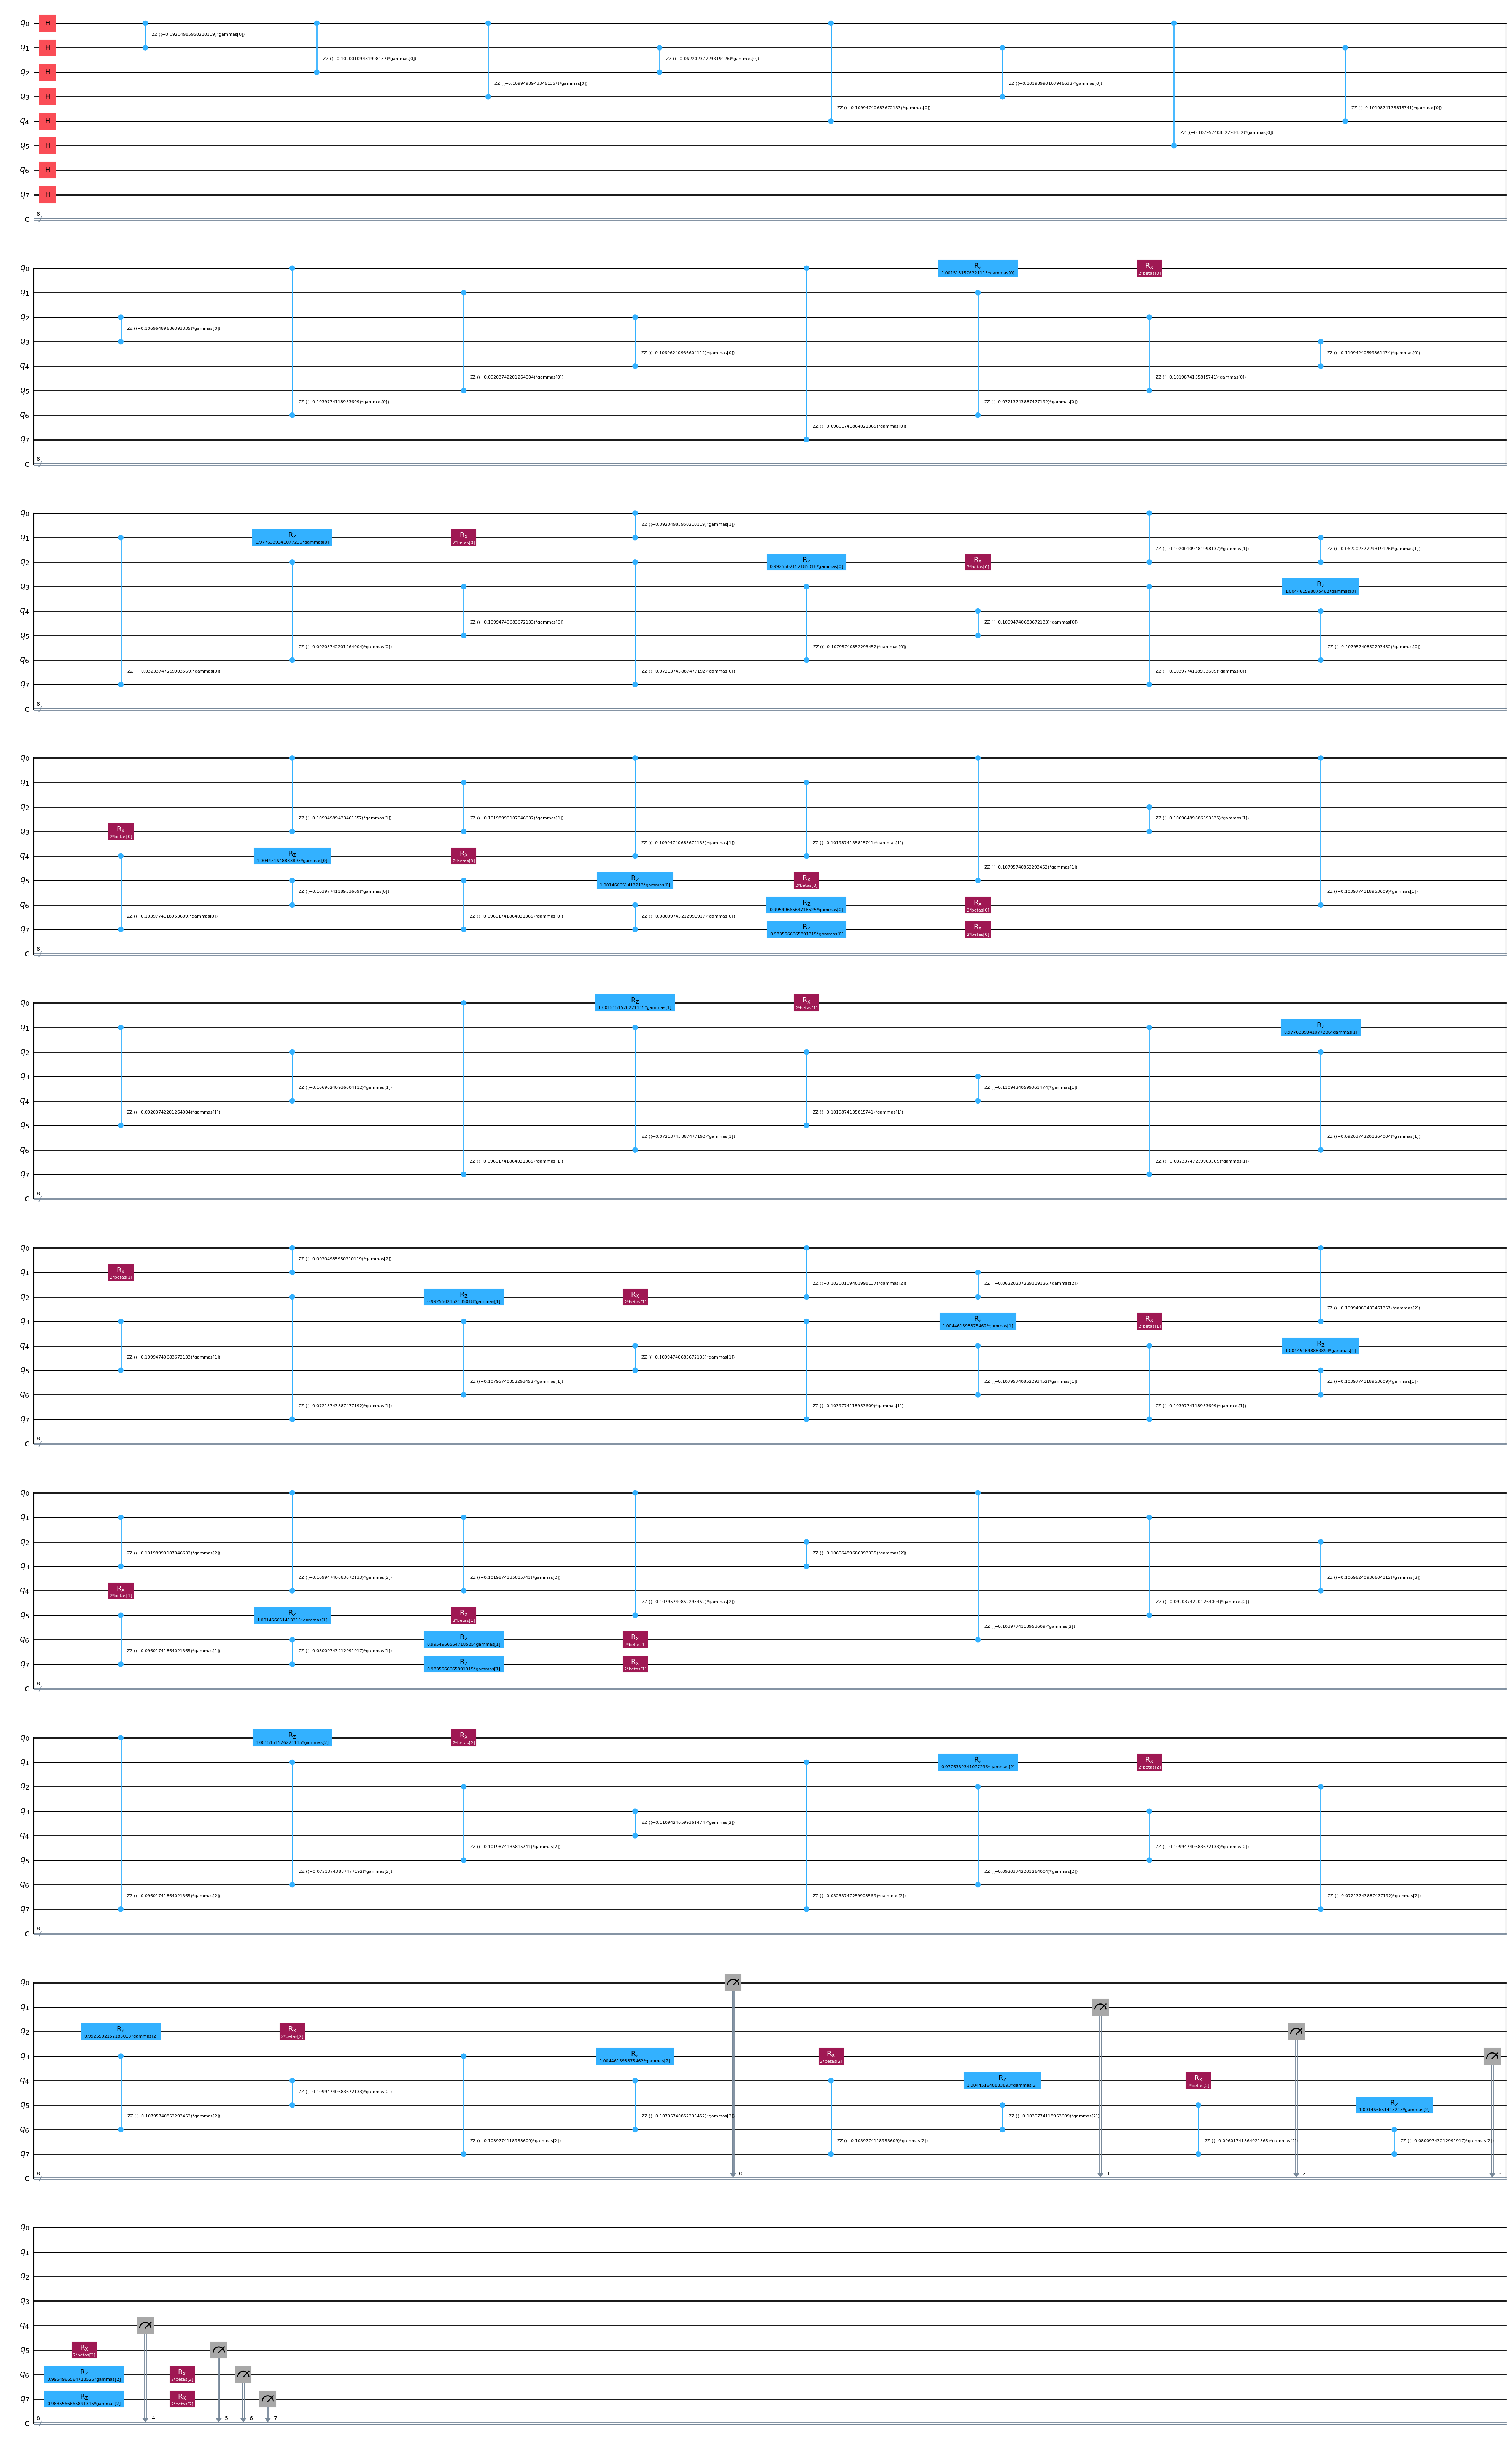

In [104]:
# Draw the parameterised QAOA circuit
# bind dummy values so Qiskit can render the gates
dummy_gammas = [0.1] * p
dummy_betas  = [0.2] * p

job_draw = executable.sample(
    transpiler.executor(backend=None),   # no backend needed for draw
    shots=1,
    bindings={'gammas': dummy_gammas, 'betas': dummy_betas},
)

circuit = executable.get_first_circuit()
circuit.draw('mpl', fold=60)


---
## 5 · VQA optimisation

The classical outer loop minimises $\langle H_C \rangle$ over the $2p$ parameters
$(\boldsymbol{\gamma}, \boldsymbol{\beta})$ using COBYLA — a gradient-free optimizer
well-suited to noisy quantum evaluations.

At each iteration:
1. Bind the current parameters into the circuit
2. Sample bitstrings from the Aer simulator
3. Decode samples and compute mean energy $\langle H_C \rangle$
4. Return the energy to the optimizer

In [105]:
from qiskit_aer import AerSimulator
from scipy.optimize import minimize

executor = transpiler.executor(backend=AerSimulator(seed_simulator=114))
rng = np.random.default_rng(114)
initial_params = rng.uniform(-np.pi / 2, np.pi / 2, 2 * p)
cost_history = []

def cost_fn(params):
    gammas = list(params[:p])
    betas  = list(params[p:])
    job    = executable.sample(
        executor,
        shots=4096,
        bindings={'gammas': gammas, 'betas': betas},
    )
    result  = job.result()
    decoded = converter.decode(result)
    energy  = decoded.energy_mean()
    cost_history.append(energy)
    return energy

res = minimize(
    cost_fn,
    initial_params,
    method='COBYLA',
    options={'maxiter': 300},
)

print(f'Optimised cost      : {res.fun:.4f}')
print(f'Function evaluations: {res.nfev}')
print(f'Optimal gamma : {[round(v, 4) for v in res.x[:p]]}')
print(f'Optimal beta : {[round(v, 4) for v in res.x[p:]]}')

Optimised cost      : -15.8131
Function evaluations: 77
Optimal gamma : [np.float64(0.5106), np.float64(-0.9867), np.float64(-0.0338)]
Optimal beta : [np.float64(1.6), np.float64(0.3241), np.float64(0.4549)]


---
## 6 · VQA convergence plot

The convergence curve shows how the mean energy $\langle H_C \rangle$ decreases
as the classical optimizer refines the parameters. A well-converged VQA should
show a smooth descent that flattens near the optimum.

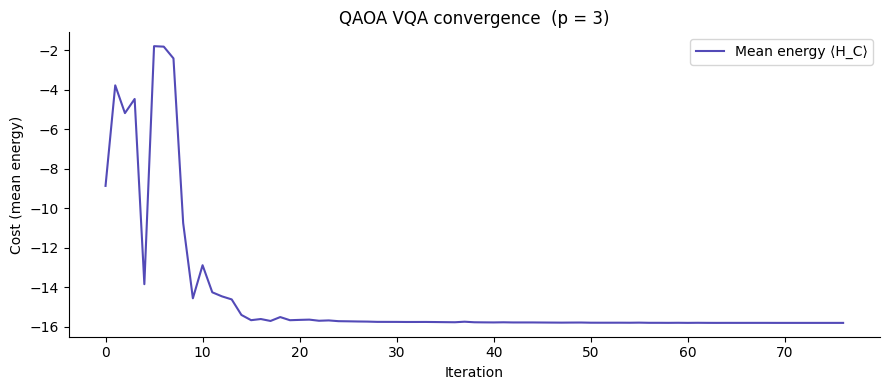

In [106]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(cost_history, color='#534AB7', linewidth=1.5, label='Mean energy ⟨H_C⟩')
ax.set_xlabel('Iteration')
ax.set_ylabel('Cost (mean energy)')
ax.set_title(f'QAOA VQA convergence  (p = {p})')
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('qaoa_convergence.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7 · Sample with optimised parameters and decode

In [107]:
gammas_opt = list(res.x[:p])
betas_opt  = list(res.x[p:])

sample_result = executable.sample(
    executor,
    shots=4096,
    bindings={'gammas': gammas_opt, 'betas': betas_opt},
).result()

decoded = converter.decode(sample_result)
print(f'Total samples: {sum(decoded.num_occurrences)}')

Total samples: 4096


In [108]:
feasible_results = []
for sample, occ in zip(decoded.samples, decoded.num_occurrences):
    x_vec = np.array([sample.get(i, 0) for i in range(n)], dtype=int)
    Z, w_used, feasible = evaluate(x_vec)
    if feasible:
        feasible_results.append({'x': x_vec, 'Z': Z, 'weight': w_used, 'occ': occ})

total_feasible = sum(r['occ'] for r in feasible_results)
total_samples  = sum(decoded.num_occurrences)
print(f'Feasible samples: {total_feasible} / {total_samples} '
      f'({100 * total_feasible / total_samples:.1f}%)')

if feasible_results:
    feasible_results.sort(key=lambda r: r['occ'], reverse=True)
    best = feasible_results[0]
    print(f'Best feasible solution: {dict(enumerate(best["x"].tolist()))}')
    print(f'Selected : {[ITEMS[i] for i in range(n) if best["x"][i] == 1]}')
    print(f'Value Z  : {best["Z"]:.2f}')
    print(f'Weight   : {int(best["weight"])} / {int(W_cap)}')
    print(f'Occurrences: {best["occ"]}')
else:
    print('No feasible solution found. Try increasing p or maxiter.')
    best = None

Feasible samples: 29 / 4096 (0.7%)
Best feasible solution: {0: 1, 1: 1, 2: 0, 3: 1}
Selected : ['SHANG', 'BBQ', 'CD']
Value Z  : 30.00
Weight   : 260 / 300
Occurrences: 6


---
## 9 · Comparison across all solvers

In [109]:
import pandas as pd

Z_qaoa = best['Z'] if feasible_results else None

summary = pd.DataFrame([
    {'Solver': 'CVXPY (exact)', 'Best Z': Z_classical,
     'Optimality gap': '0.0%', 'Selected': str([ITEMS[i] for i in range(n) if x_opt[i]==1])},
    {'Solver': 'QAOA (Qiskit Aer)', 'Best Z': round(Z_qaoa, 2) if Z_qaoa else 'N/A',
     'Optimality gap': f'{(Z_classical-Z_qaoa)/Z_classical*100:.1f}%' if Z_qaoa else 'N/A',
     'Selected': str([ITEMS[i] for i in range(n) if best['x'][i]==1]) if feasible_results else 'N/A'},
]).set_index('Solver')

print(summary.to_string())

                   Best Z Optimality gap                Selected
Solver                                                          
CVXPY (exact)        30.0           0.0%  ['SHANG', 'BBQ', 'CD']
QAOA (Qiskit Aer)    30.0           0.0%  ['SHANG', 'BBQ', 'CD']


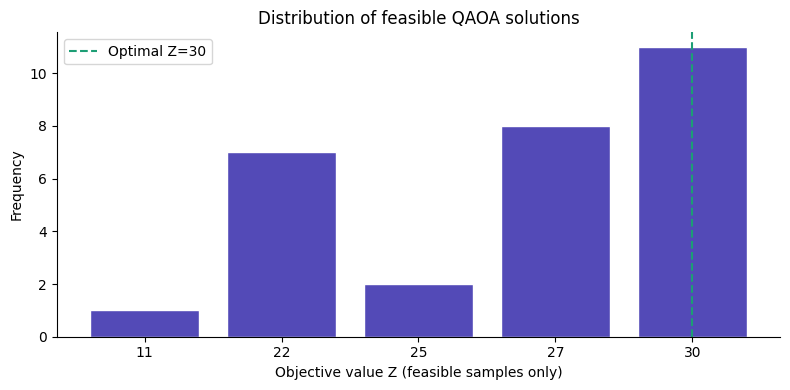

In [110]:
# ── Solution quality distribution ─────────────────────────────────────────────
if feasible_results:
    from collections import defaultdict
    Z_counts = defaultdict(int)
    for r in feasible_results:
        Z_counts[r['Z']] += r['occ']

    fig, ax = plt.subplots(figsize=(8, 4))
    zvals  = sorted(Z_counts.keys())
    counts = [Z_counts[z] for z in zvals]
    ax.bar([str(int(z)) for z in zvals], counts, color='#534AB7', edgecolor='white')
    ax.axvline(x=zvals.index(Z_classical) if Z_classical in zvals else -1,
               color='#1D9E75', linestyle='--', linewidth=1.5, label=f'Optimal Z={int(Z_classical)}')
    ax.set_xlabel('Objective value Z (feasible samples only)')
    ax.set_ylabel('Frequency')
    ax.set_title('Distribution of feasible QAOA solutions')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig('qaoa_solution_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

---
## 10 · Summary

| | CVXPY | SA / SQA | QAOA |
|---|---|---|---|
| **Type** | Exact MILP | Classical/quantum-inspired heuristic | Variational quantum algorithm |
| **Hardware** | CPU | CPU | Quantum simulator / QPU |
| **Constraint handling** | Hard | Soft QUBO penalty | Soft QUBO penalty |
| **Parameters to tune** | None | λ (penalty) | λ (penalty), p (layers), optimizer |
| **Scalability** | Exponential | Polynomial per sweep | Polynomial gates, exponential classical sim |

**Key points:**
- The QAOA circuit has **n qubits** (one per item) and **2p parameters** (γ, β per layer).
- The cost Hamiltonian $H_C$ is derived directly from the QUBO — the same penalty encoding used for SA/SQA.
- More layers $p$ improve solution quality but increase gate depth and optimisation cost.
- On a real QPU, gate noise limits practical $p$ to small values (typically $p \leq 5$ on current hardware).
- For n=4 all methods find the optimum: **SHANG + BBQ**, Z=25, weight=240 ≤ 300.